In [170]:
import pandas as pd
import sqlite3

con = sqlite3.connect("C:/Users/fathi/Downloads/ipl sem 3/IPL-Cricket-Analyticss/data/raw/ipl.db")
def q(sql):
    return pd.read_sql(sql,con)

In [171]:
q("""
SELECT name
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY name;
""")

,name
0,deliveries
1,matches
2,matches_clean
3,players
4,teams
5,v_match_totals
6,v_matches_clean
7,venues


In [172]:
q("""
WITH per_season AS (
    SELECT DISTINCT season, COUNT(*) AS matches
    FROM matches
    GROUP BY season
)
SELECT season, matches
From per_season
ORDER BY matches DESC
LIMIT 3
""")

,season,matches
0,2013,76
1,2012,74
2,2022,74


In [173]:
q("""
WITH per_season AS (
    SELECT DISTINCT season, COUNT(*) AS matches
    FROM matches
    GROUP BY season
)

SELECT COUNT(*) AS seasons,
MAX( matches) AS busiest
FROM per_season;
""")

,seasons,busiest
0,19,76


In [174]:
q("""
WITH totals AS(
SELECT  batter, SUM(batter_runs)  AS runs
FROM deliveries
GROUP BY batter)

SELECT batter, runs,
RANK() OVER( ORDER BY runs DESC) AS rk
FROM totals
ORDER BY  rk
LIMIT 5;
""")

,batter,runs,rk
0,V Kohli,9050,1
1,RG Sharma,7185,2
2,S Dhawan,6769,3
3,DA Warner,6567,4
4,KL Rahul,5668,5


**1st innings**= the team that wins the toss gets their turn to bat for maximum of 20 overs to set a target score.

**2nd innings**= the opposite team then gets their turn to bat for 20 overs to chase down that target score

JOIN+CTE WINDOW FUNCTION

In [175]:
q("""
SELECT COUNT(*) AS before_joint
FROM  matches_clean""")

,before_joint
0,1212


In [176]:
q("""
WITH ranked_venues AS(
      SELECT *,
      ROW_NUMBER() OVER(PARTITION BY venue
      ORDER BY venue_id) AS rn
      FROM venues),
dedup_venues AS(
    SELECT *
    FROM ranked_venues
    WHERE rn=1)
SELECT COUNT(*) AS after_join
FROM matches_clean m
LEFT JOIN dedup_venues v
ON m.venue = v.venue;""")

,after_join
0,1212


In [177]:
q("""
WITH first_innings AS (
  SELECT  match_id,
       SUM(total_runs) AS first_innings_total
  FROM deliveries
   WHERE innings=1
    GROUP BY match_id )
   SELECT *
   FROM first_innings
   LIMIT 10;""")

,match_id,first_innings_total
0,335982,222
1,335983,240
2,335984,129
3,335985,165
4,335986,110
5,335987,166
6,335988,142
7,335989,208
8,335990,214
9,335991,182


VERIFYING CTE

In [178]:
q("""
SELECT match_id,innings,
SUM(total_runs) AS check_total
FROM deliveries
WHERE match_id=335982
AND innings=1
GROUP BY match_id,innings;""")

,match_id,innings,check_total
0,335982,1,222


In [179]:
q("""
SELECT match_id,
SUM(total_runs) AS check_total
FROM deliveries
WHERE match_id IN (335982,335983,335984,335985,335986)
AND innings=1
GROUP BY match_id
ORDER BY match_id;""")

,match_id,check_total
0,335982,222
1,335983,240
2,335984,129
3,335985,165
4,335986,110


In [180]:
q("""
SELECT match_id,
COUNT(DISTINCT batting_team) AS batting_team
FROM deliveries
WHERE innings=1
GROUP BY match_id
HAVING COUNT(DISTINCT batting_team)!=1;""")


,match_id,batting_team


In [181]:
q("""
WITH first_innings AS (
  SELECT  match_id,batting_team AS innings1_batting_team,
       SUM(total_runs) AS first_innings_total
  FROM deliveries
   WHERE innings=1
    GROUP BY match_id,batting_team )
   SELECT *
   FROM first_innings
   LIMIT 10;""")

,match_id,innings1_batting_team,first_innings_total
0,335982,Kolkata Knight Riders,222
1,335983,Chennai Super Kings,240
2,335984,Rajasthan Royals,129
3,335985,Mumbai Indians,165
4,335986,Sunrisers Hyderabad,110
5,335987,Punjab Kings,166
6,335988,Sunrisers Hyderabad,142
7,335989,Chennai Super Kings,208
8,335990,Sunrisers Hyderabad,214
9,335991,Punjab Kings,182


In [182]:
q("""
WITH first_innings AS (
     SELECT match_id,batting_team AS innings1_batting_team,
     SUM(total_runs) AS first_innings_total
     FROM deliveries
     WHERE innings = 1
     GROUP BY match_id,batting_team)
SELECT m.match_id,m.season_year,f.innings1_batting_team,f.first_innings_total
FROM matches_clean m
LEFT JOIN first_innings f ON m.match_id = f.match_id
LIMIT 5;""")

,match_id,season_year,innings1_batting_team,first_innings_total
0,335982,2008,Kolkata Knight Riders,222
1,1082591,2017,Sunrisers Hyderabad,207
2,1082592,2017,Mumbai Indians,184
3,1082593,2017,Gujarat Lions,183
4,1082594,2017,Rising Pune Supergiant,163


In [183]:
con.executescript("""
DROP VIEW IF EXISTS v_match_totals;

CREATE VIEW v_match_totals AS
WITH first_innings AS (
    SELECT 
        match_id,
        batting_team AS innings1_batting_team,
        SUM(total_runs) AS first_innings_total
    FROM deliveries
    WHERE innings = 1
    GROUP BY match_id, batting_team
)
SELECT 
    m.*,
    f.innings1_batting_team,
    f.first_innings_total
FROM matches_clean m
LEFT JOIN first_innings f 
    ON m.match_id = f.match_id;
""")

con.commit()

In [184]:
q("""
SELECT COUNT(*) AS total_rows
FROM v_match_totals;""")

,total_rows
0,1212


**LAG()**= it is a window function that lets view look back at data from a previous row

season=2021,2022,2023 & 
matches=60,74,74

lag apply = season=2021,2022,2023 & 
matches=60,74,74 & previous = NULL,60,74

season on = season change => 2022-2021-74-60 = 14

In [185]:
q("""
SELECT season ,COUNT(DISTINCT match_id) AS season_counts
FROM matches_clean 
GROUP BY season_year
ORDER BY season_counts ASC;""")

,season,season_counts
0,2026,43
1,2009,57
2,2008,58
3,2015,59
4,2017,59
5,2010,60
6,2014,60
7,2016,60
8,2018,60
9,2019,60


In [186]:
q("""WITH season_counts AS (SELECT season_year,
COUNT(*) as matches
FROM matches_clean
GROUP BY season_year)
SELECT season_year,matches,
LAG(matches) OVER(ORDER BY season_year) AS previous_season_matches
FROM season_counts
ORDER BY season_year;""")

,season_year,matches,previous_season_matches
0,2008,58,NaN
1,2009,57,58.0
2,2010,60,57.0
3,2011,73,60.0
4,2012,74,73.0
5,2013,76,74.0
6,2014,60,76.0
7,2015,59,60.0
8,2016,60,59.0
9,2017,59,60.0


In [187]:
q("""
WITH season_counts AS (
    SELECT 
        season_year,
        COUNT(*) AS matches
    FROM matches_clean
    GROUP BY season_year
)
SELECT 
    season_year,
    matches,
    LAG(matches) OVER(ORDER BY season_year) AS previous_season_matches,
    matches - LAG(matches) OVER(ORDER BY season_year) AS season_change
FROM season_counts
ORDER BY season_year;
""")

,season_year,matches,previous_season_matches,season_change
0,2008,58,NaN,NaN
1,2009,57,58.0,-1.0
2,2010,60,57.0,3.0
3,2011,73,60.0,13.0
4,2012,74,73.0,1.0
5,2013,76,74.0,2.0
6,2014,60,76.0,-16.0
7,2015,59,60.0,-1.0
8,2016,60,59.0,1.0
9,2017,59,60.0,-1.0


**POWER PLAY**=
A specific set of overs at the start of an innings where the fielding team must keep most of their players close to the center,creating big gaps in the out field to help batters score more runs.

**DEATH OVERS**=Final few overs ,batters try to score as many runs as possible by hitting boundries and sixes.bowlers try to stop runs and take wickets using slow balls.

**CHASING VS DEFENDING**= chasing means batting second to scores more runs that the target set by the first team,while defending means bowling and fielding second to stop batting team from reaching that target.

In [188]:
q("""
SELECT 
MIN(over_number) AS  min_over,
MAX(over_number) AS max_over,
COUNT(DISTINCT over_number) AS distinct_overs
FROM deliveries
WHERE is_super_over=0;""")

,min_over,max_over,distinct_overs
0,0,19,20


Super over =Both teams get 1 over each

0-19 overs

6-14 middle overs

0 -6 powerplay

In [189]:
q("""
SELECT 
   ROUND(6.0*SUM(total_runs)/COUNT(*),2)
   AS powerplay_rpo
   FROM deliveries
   WHERE is_super_over=0
   AND is_wide_ball=0
   AND is_no_ball=0
   AND over_number BETWEEN 0 AND 5;
""")

,powerplay_rpo
0,7.71


15-19 death over

In [190]:
q("""
SELECT 
   ROUND(6.0*SUM(total_runs)/COUNT(*),2)
   AS death_overs
   FROM deliveries
   WHERE is_super_over=0
   AND is_wide_ball=0
   AND is_no_ball=0
   AND over_number BETWEEN 15 AND 19;
""")

,death_overs
0,9.61


In [191]:
q("""
SELECT 
   ROUND(100.0*SUM(is_wicket)/COUNT(*),2)
   AS powerplay_wicket_rate
   FROM deliveries
   WHERE is_super_over=0
   AND is_wide_ball=0
   AND is_no_ball=0
   AND over_number BETWEEN 0 AND 5;
""")

,powerplay_wicket_rate
0,4.0


In [192]:
q("""
SELECT 
   ROUND(100.0*SUM(is_wicket)/COUNT(*),2)
   AS deathover_wicket_rate
   FROM deliveries
   WHERE is_super_over=0
   AND is_wide_ball=0
   AND is_no_ball=0
   AND over_number BETWEEN 15 AND 19;
""")

,deathover_wicket_rate
0,8.41


DEATH over are harder to bowl beacuse scoring is higher and wickets also fall much more frequently

middle overs 6-14

In [193]:
q("""
SELECT 
   ROUND(6.0*SUM(total_runs)/COUNT(*),2)
   AS middleovers
   FROM deliveries
   WHERE is_super_over=0
   AND is_wide_ball=0
   AND is_no_ball=0
   AND over_number BETWEEN 6  AND 14;
""")

,middleovers
0,7.67


DOT BALL- a delivery in which the batter scores 0 runs 

DOT BALL %

In [194]:
q("""
SELECT 
   ROUND (100.0*SUM(CASE WHEN batter_runs=0 THEN 1 ELSE 0 END)/COUNT(*),2)
   AS batter_dot
   FROM deliveries
   WHERE is_super_over=0
   AND is_wide_ball=0
   AND is_no_ball=0;
""")

,batter_dot
0,37.45


100 legal bowls =37.45 a batsman no runs

In [195]:
q("""
SELECT 
   ROUND(100.0*SUM(CASE WHEN total_runs=0 THEN 1 ELSE 0 END)/COUNT(*),2)
   AS team_dot
   FROM deliveries
   WHERE is_super_over=0
   AND is_wide_ball=0
   AND is_no_ball=0;
""")

,team_dot
0,35.64


In [196]:
##ANALYSIS

1-number/finding

2-what exactly was counted

3-population it came from

4-what decision would this finding change?

venue_analysis

In [197]:
q("""
SELECT venue_clean, COUNT(*) as matches
FROM matches_clean
GROUP BY venue_clean
ORDER BY matches DESC
LIMIT 10;
""")

,venue_clean,matches
0,Wankhede Stadium,130
1,M Chinnaswamy Stadium,104
2,Eden Gardens,104
3,MA Chidambaram Stadium,95
4,Rajiv Gandhi International Stadium,87
5,Sawai Mansingh Stadium,66
6,Feroz Shah Kotla,60
7,Dubai International Cricket Stadium,46
8,Arun Jaitley Stadium,41
9,Narendra Modi Stadium,37


-1-wankhede stadium 130 matches

2-no of matches played at wankhede stadium using the clean venue field.

3-All matches in matches_clean

4-Helps ensure venue level analysis and comparisons are based on cleaned venue names rather than fragmented row names.

TOSS winner also WINS?

decisive match -a match that entered with a clear winner

In [198]:
q("""
SELECT 
 COUNT(*) AS desisive_matches,
 SUM(CASE WHEN toss_winner=match_winner THEN 1 ELSE 0 END)AS toss_winner_wins,
 ROUND(100.0*SUM(CASE WHEN toss_winner=match_winner THEN 1 ELSE 0 END)/COUNT(*),2)AS percentage
 FROM matches_clean
 WHERE result='win';""")

,desisive_matches,toss_winner_wins,percentage
0,1187,613,51.64


1- 613 of 1187 (51.64%)

2- matches where toss_winner = match_winner

3-1187 decisive matches where result = win

4-Helps access whether winning the toss is accossiated with a meaningfull match winning adavantage.

In [199]:
q("""SELECT season_year, 
COUNT(*) AS total_matches,
SUM(CASE WHEN
 toss_decision= 'field' THEN 1 ELSE 0 END) AS field_first,
ROUND(100.0*SUM(CASE WHEN toss_decision= 'field' THEN 1 ELSE 0 END)
/COUNT(*),2) AS field_first_pct
FROM matches_clean
GROUP BY season_year
ORDER BY season_year;""")

,season_year,total_matches,field_first,field_first_pct
0,2008,58,32,55.17
1,2009,57,22,38.60
2,2010,60,21,35.00
3,2011,73,48,65.75
4,2012,74,37,50.00
5,2013,76,31,40.79
6,2014,60,41,68.33
7,2015,59,34,57.63
8,2016,60,49,81.67
9,2017,59,48,81.36


-55.17% in 2008,38.6% in 2009,35% in 2010,above 80% 2016 and 2019.

2-percentage of matches in each season where toss winning team choose to field.

3-all matches in each season in matches_clean

4-Helps identify how toss strategy and preference for fielding first change over time.

FEILD -FIRST TREND

CAUGHT DISSMISSES- when batter hits the ball with their gloved hand holding the bat ,and fielder or the bowler catches the bowl in their thh air before it touches the ground 

In [200]:
q("""
SELECT COUNT(*) AS caught_dissmissals
FROM deliveries
WHERE wicket_kind='caught';""")

,caught_dissmissals
0,9056


1-caught dismissals = 9056

2-delivery records there wicket_kind= caught

3- dismissals records in the delivery table

4- helps identify how important caught dismissals are as mode of taking wickets

chase win_rate -A chase win rate is the percentage of matches wonned by the team batting2

In [201]:
q("""
SELECT COUNT(*) desicive_match 
FROM v_match_totals
WHERE result ='win'""")

,desicive_match
0,1187


In [202]:
q('''
SELECT
    CASE
        WHEN first_innings_total < 140 THEN 'Under 140'
        WHEN first_innings_total BETWEEN 140 AND 159 THEN '140-159'
        WHEN first_innings_total BETWEEN 160 AND 179 THEN '160-179'
        WHEN first_innings_total BETWEEN 180 AND 199 THEN '180-199'
        ELSE '200+'
    END AS score_band,
    COUNT(*) AS matches
FROM v_match_totals
WHERE result = 'win'
    AND first_innings_total IS NOT NULL
GROUP BY score_band;
''')

,score_band,matches
0,140-159,241
1,160-179,312
2,180-199,217
3,200+,198
4,Under 140,219


In [203]:
q('''
SELECT
    match_id,
    first_innings_total,
    innings1_batting_team,
    match_winner,
    CASE
        WHEN match_winner != innings1_batting_team THEN 1
        ELSE 0
    END AS chase_win
FROM v_match_totals
WHERE result ='win'
    AND first_innings_total IS NOT NULL
LIMIT 10;
''')

,match_id,first_innings_total,innings1_batting_team,match_winner,chase_win
0,335982,222,Kolkata Knight Riders,Kolkata Knight Riders,0
1,1082591,207,Sunrisers Hyderabad,Sunrisers Hyderabad,0
2,1082592,184,Mumbai Indians,Rising Pune Supergiant,1
3,1082593,183,Gujarat Lions,Kolkata Knight Riders,1
4,1082594,163,Rising Pune Supergiant,Punjab Kings,1
5,1082595,157,Royal Challengers Bangalore,Royal Challengers Bangalore,0
6,1082596,135,Gujarat Lions,Sunrisers Hyderabad,1
7,1082597,178,Kolkata Knight Riders,Mumbai Indians,1
8,1082598,148,Royal Challengers Bangalore,Punjab Kings,1
9,1082599,205,Delhi Capitals,Delhi Capitals,0


In [204]:
q('''
WITH chase_data AS (
    SELECT
        first_innings_total,
        
        CASE
            WHEN first_innings_total < 140 THEN 'Under 140'
            WHEN first_innings_total BETWEEN 140 AND 159 THEN '140-159'
            WHEN first_innings_total BETWEEN 160 AND 179 THEN '160-179'
            WHEN first_innings_total BETWEEN 180 AND 199 THEN '180-199'
            ELSE '200+'
        END AS score_band,
        CASE
            WHEN match_winner != innings1_batting_team THEN 1
        ELSE 0
    END AS chase_win
FROM v_match_totals
WHERE result ='win'
    AND first_innings_total IS NOT NULL
)

SELECT
    score_band,
    COUNT(*) AS sample_size,
    ROUND(
        100.0*SUM(chase_win)/COUNT(*),
        1
        ) AS chase_win_rate
FROM chase_data
GROUP BY score_band
ORDER BY 
    CASE score_band
        WHEN 'Under 140' THEN 1
        WHEN '140-159' THEN 2
        WHEN '169-179' THEN 3
        WHEN '180-199' THEN 4
        WHEN '200+' THEN 5
    END;
''')

,score_band,sample_size,chase_win_rate
0,160-179,312,53.2
1,Under 140,219,82.6
2,140-159,241,71.0
3,180-199,217,38.2
4,200+,198,23.2


higher first innings totals correspond to lower chase win rates

In [205]:
q('''
SELECT
    COUNT(*) AS matches,
    SUM(
        CASE
            WHEN win_by_wickets IS NOT NULL THEN 1
            ELSE 0
        END
    ) AS chase_wins,
    ROUND(100.0 * SUM(CASE WHEN win_by_wickets IS NOT NULL THEN 1 ELSE 0 END)
      / COUNT(*),
      1)AS chase_win_rate
FROM v_match_totals
WHERE result ='win'
    AND first_innings_total < 140;
''')

,matches,chase_wins,chase_win_rate
0,219,177,80.8


In [206]:
q("""
WITH chase_defs AS (
    SELECT
        match_id,

        CASE
            WHEN match_winner != innings1_batting_team THEN 1
            ELSE 0
        END AS definition_1,

        CASE
            WHEN win_by_wickets IS NOT NULL THEN 1
            ELSE 0
        END AS definition_2

    FROM v_match_totals
    WHERE result = 'win'
      AND first_innings_total IS NOT NULL
)

SELECT
    COUNT(*) AS total_matches,
    SUM(
        CASE
            WHEN definition_1 = definition_2 THEN 1
            ELSE 0
        END
    ) AS agreements,
    SUM(
        CASE
            WHEN definition_1 != definition_2 THEN 1
            ELSE 0
        END
    ) AS disagreements,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN definition_1 = definition_2 THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        1
    ) AS agreement_pct
FROM chase_defs;
""")

,total_matches,agreements,disagreements,agreement_pct
0,1187,1181,6,99.5


the two chase definitions agree on 1181 out of 1187 decing matches or 99.5% they disagree on only 6 matches but those six are enough to slightly change the reported chase win rate.

In [207]:
chase_bands = q("""
WITH chase_data AS (
    SELECT
        first_innings_total,

        CASE
            WHEN first_innings_total < 140 THEN 'Under 140'
            WHEN first_innings_total BETWEEN 140 AND 159 THEN '140-159'
            WHEN first_innings_total BETWEEN 160 AND 179 THEN '160-179'
            WHEN first_innings_total BETWEEN 180 AND 199 THEN '180-199'
            ELSE '200+'
        END AS score_band,

        CASE
            WHEN match_winner != innings1_batting_team THEN 1
            ELSE 0
        END AS chase_win

    FROM v_match_totals
    WHERE result = 'win'
      AND first_innings_total IS NOT NULL
)

SELECT
    score_band,
    COUNT(*) AS sample_size,
    ROUND(
        100.0 * SUM(chase_win) / COUNT(*),
        1
    ) AS chase_win_rate
FROM chase_data
GROUP BY score_band
ORDER BY
    CASE score_band
        WHEN 'Under 140' THEN 1
        WHEN '140-159' THEN 2
        WHEN '160-179' THEN 3
        WHEN '180-199' THEN 4
        WHEN '200+' THEN 5
    END;
""")

chase_bands

,score_band,sample_size,chase_win_rate
0,Under 140,219,82.6
1,140-159,241,71.0
2,160-179,312,53.2
3,180-199,217,38.2
4,200+,198,23.2


matplot library - it is a popular open sourse python library use for creating static,interactive and animated data visualizations

different charts and their uses- line chart= to show trends or changes over time(plt.plot(x,y))
bar chart= to compare quantity across different categories(plt.bar(x,y))
scatter plot= to observe relationship,pattern,or core relation btw to variables(plt.scatter(x,y))
Histogram = to show the frequency distribution of data(plt.his(x))
pie chart= display propotion,percentages or part to whole data (plt.pie(x))
box plot = to easily see the spread,variability,and outliers with in a dataset(plt.boxplot(x))

**CHART INSTRUCTION:**   
 
1.create one chart for each finding.   

2.do not create a chart unless there is a clear finding behind it.   

3.use a clear,plain language title 

4.the title should describe the finding,not simply list variable names.
5.label both axis clearly and include units 

6.use sensible sortings sort categorical bar charts approproriplty by value,and key time series charts in chronological order.

state the filter context whenever a threshold filter has been applied ?  economy rate 

1.show the sample size on every bar of a bar chart,    

2.a percentaage or rate should not been presented without its denominator label the population and sample size on the chart itself,
   
3.every chart included in the analysis report should support  a specific finding and its corresponding buisness correction.

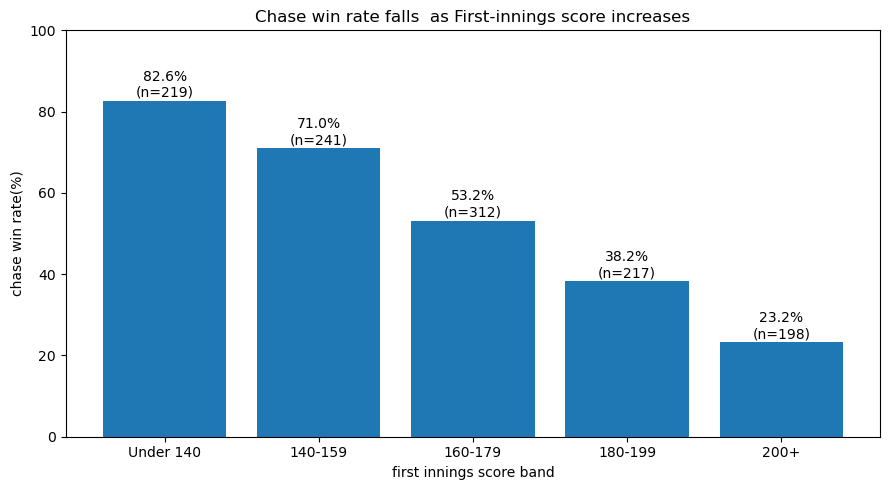

In [208]:
plt.figure(figsize=(9,5))
bars=plt.bar(
    chase_bands['score_band'],
    chase_bands['chase_win_rate']
)
plt.title("Chase win rate falls  as First-innings score increases")
plt.xlabel('first innings score band')
plt.ylabel('chase win rate(%)')
for bar,rate,n in zip(
    bars,chase_bands['chase_win_rate'],
    chase_bands['sample_size']):
    plt.text(
        bar.get_x()+ bar.get_width()/2,
        bar.get_height()+1,
        f"{rate}%\n(n={n})",
        ha='center'
    )
plt.ylim(0,100)
plt.tight_layout()
plt.show()

This code creates a bar chart showing how chasse_win_rates changes across diffrent first innings score bands 

Matplotlib.pyplot is imported as plt to create a chart ,and fig size controls the chart size .  
plt.bar uses score bands in the x axis and chase _wins_rates on the y axis.the chart includes a clear title and lablled axis with the percentage unit. a for loop with zip goes through each bar and adds the win_rate and sample size n above it .  
plt,ylim(0,100) sets the percentage scale from 0 to 100 .
Tight_layout -adjusts the spacing ,plt.show-displays the completed chart

Finding v/s Insights   
Finding-what we find out  
Insights-finding + what action to take

**CHASE WIN**
Findings-Higher first innings totals are associated with lower chase_wins_rates  
insights-Higher first innings totals are associated with lower chase_wins_rates,so batting first teams can use this pattern when deciding what total to target and how aggresively to pursue additional runs.

**ANALYSIS REPORT**  

1. 3+ insights + actions  
2. 1 data limitation  
3. Properly lablled charts  
4. 1 SQL result verified in Excel

In [211]:
toss_chart=q("""
SELECT
       CASE 
            WHEN toss_winner=match_winner
            THEN 'Toss Winner Won Match'
            ELSE 'Toss Winner Did Not Win' 
        END AS outcome,
        COUNT(*) AS matches
FROM matches_clean
WHERE result='win' 
GROUP BY outcome;
""")
toss_chart

,outcome,matches
0,Toss Winner Did Not Win,574
1,Toss Winner Won Match,613


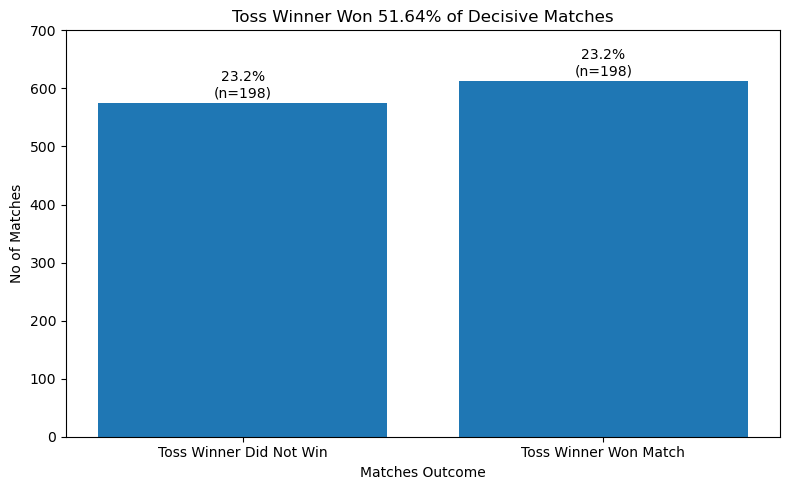

In [212]:
plt.figure(figsize=(8,5))
bars=plt.bar(
    toss_chart['outcome'],
    toss_chart['matches']
)
plt.title("Toss Winner Won 51.64% of Decisive Matches")
plt.xlabel('Matches Outcome')
plt.ylabel('No of Matches')
for bar,value in zip(
    bars,toss_chart['matches']):
    plt.text(
        bar.get_x()+ bar.get_width()/2,
        bar.get_height()+10,
        f"{rate}%\n(n={n})",
        ha='center'
    )
plt.ylim(0,700)
plt.tight_layout()
plt.show()

In [215]:
field_first=q("""
SELECT 
      season_year,
      COUNT(*) AS total_matches,
      SUM(CASE WHEN toss_decision='field' THEN 1 ELSE 0 END) AS field_first,
      ROUND(
           100.0*SUM(CASE WHEN toss_decision='field' THEN 1 ELSE 0 END)/COUNT(*),2) AS field_first_pct
FROM matches_clean
GROUP BY season_year
ORDER BY season_year;
""")
field_first

,season_year,total_matches,field_first,field_first_pct
0,2008,58,32,55.17
1,2009,57,22,38.60
2,2010,60,21,35.00
3,2011,73,48,65.75
4,2012,74,37,50.00
5,2013,76,31,40.79
6,2014,60,41,68.33
7,2015,59,34,57.63
8,2016,60,49,81.67
9,2017,59,48,81.36


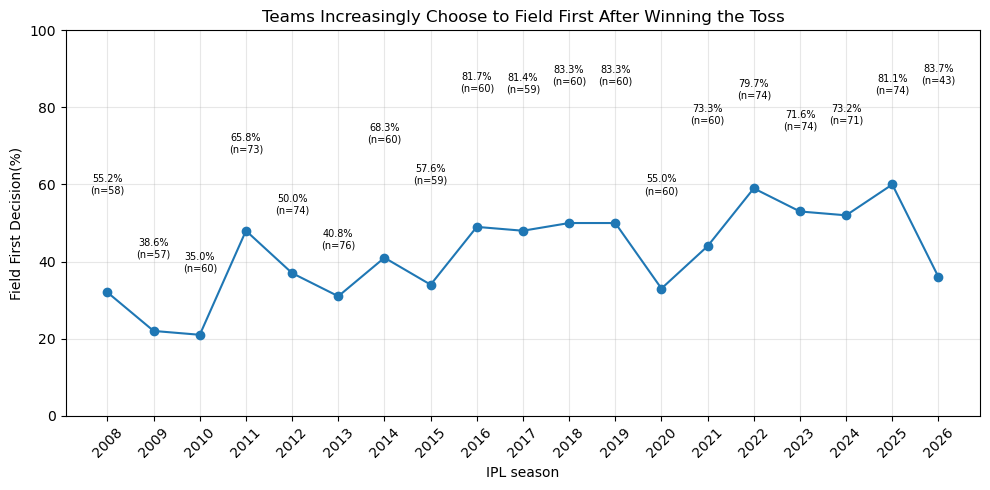

In [224]:
plt.figure(figsize=(10, 5))

plt.plot(
    field_first["season_year"],
    field_first["field_first"],
    marker="o"
)

plt.xlabel("IPL season")
plt.ylabel("Field First Decision(%)")
plt.title("Teams Increasingly Choose to Field First After Winning the Toss")
plt.xticks(field_first["season_year"], rotation=45)
for x,y,n in zip(
    field_first['season_year'],
    field_first['field_first_pct'],
    field_first['total_matches']
):
    plt.annotate(
        f"{y:.1f}%\n(n={n})",
        (x,y),
        textcoords="offset points",
        xytext=(0,7),
        ha='center',
        fontsize=7)
plt.grid(True,alpha=0.3)
plt.ylim(0,100)
plt.tight_layout()
plt.show()

**IPL Analysis Report**
This reports presents  key buisness insights 

**Insight 1--First Innings Total and Chase Success**    

   The analysis shows that the chase win rate decreases as the first-innings score increases, falling from **82.6% for scores below 140 (n=219) to 23.2% for scores of 200 or more (n=198) across 1,187 decisive matches**. This suggests that teams batting first can use higher first-innings totals to put greater pressure on the chasing team, with approximately 175 runs as a useful target to aim for. However, the analysis does not consider factors such as pitch conditions, player fitness, or injuries, which may also affect match outcomes. As a validation check, the 1,187 decisive matches identified in SQL were cross-checked in Excel, which also returned 1,187 matches.

**Insight 2--Toss Result and Match Success**     

The analysis shows that the toss winner also won the match in 613 out of 1,187 decisive matches (51.64%), while the toss winner did not win in 574 matches. This suggests that winning the toss alone does not show a strong advantage in determining the final match result, since the outcomes are nearly evenly split. Therefore, teams should not rely on the toss result alone when making match strategies and should also consider factors such as batting performance, bowling performance, and match conditions.

**Insight 3--Field-First Decisons Over Time**   
The analysis shows that the preference for fielding first after winning the toss increased over time. Field-first decisions were 55.17% in 2008, 38.60% in 2009, and 35.00% in 2010, while they exceeded 80% in each season from 2016 to 2019. This indicates a clear shift in team strategy toward choosing to chase during that period. Therefore, teams should consider the increasing preference for chasing when planning toss strategy, while also evaluating season and match conditions rather than assuming that fielding first is always the better option.


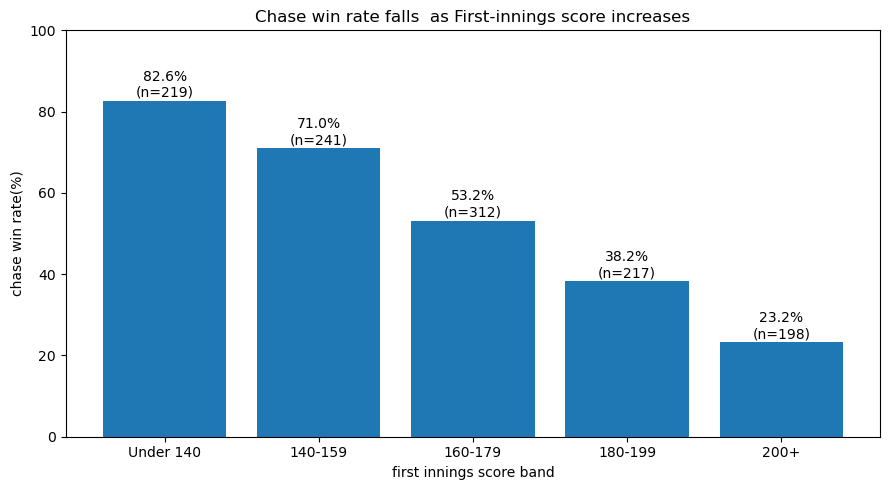

<Figure size 640x480 with 0 Axes>

In [225]:
plt.figure(figsize=(9,5))
bars=plt.bar(
    chase_bands['score_band'],
    chase_bands['chase_win_rate']
)
plt.title("Chase win rate falls  as First-innings score increases")
plt.xlabel('first innings score band')
plt.ylabel('chase win rate(%)')
for bar,rate,n in zip(
    bars,chase_bands['chase_win_rate'],
    chase_bands['sample_size']):
    plt.text(
        bar.get_x()+ bar.get_width()/2,
        bar.get_height()+1,
        f"{rate}%\n(n={n})",
        ha='center'
    )
plt.ylim(0,100)
plt.tight_layout()
plt.show()
plt.savefig(
    "../reports/figures/chase_win_rate.png",
    dpi=300,
    bbox_inches='tight')
plt.show()

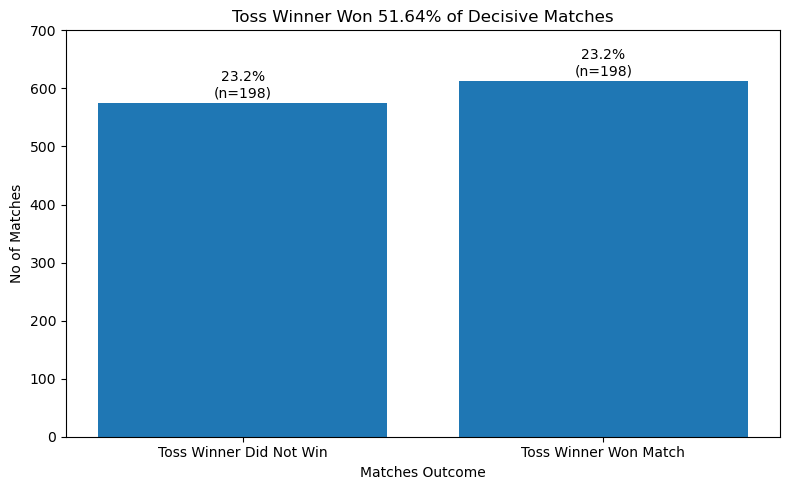

<Figure size 640x480 with 0 Axes>

In [226]:
plt.figure(figsize=(8,5))
bars=plt.bar(
    toss_chart['outcome'],
    toss_chart['matches']
)
plt.title("Toss Winner Won 51.64% of Decisive Matches")
plt.xlabel('Matches Outcome')
plt.ylabel('No of Matches')
for bar,value in zip(
    bars,toss_chart['matches']):
    plt.text(
        bar.get_x()+ bar.get_width()/2,
        bar.get_height()+10,
        f"{rate}%\n(n={n})",
        ha='center'
    )
plt.ylim(0,700)
plt.tight_layout()
plt.show()
plt.savefig(
    "../reports/figures/toss_result.png",
    dpi=300,
    bbox_inches='tight')
plt.show()

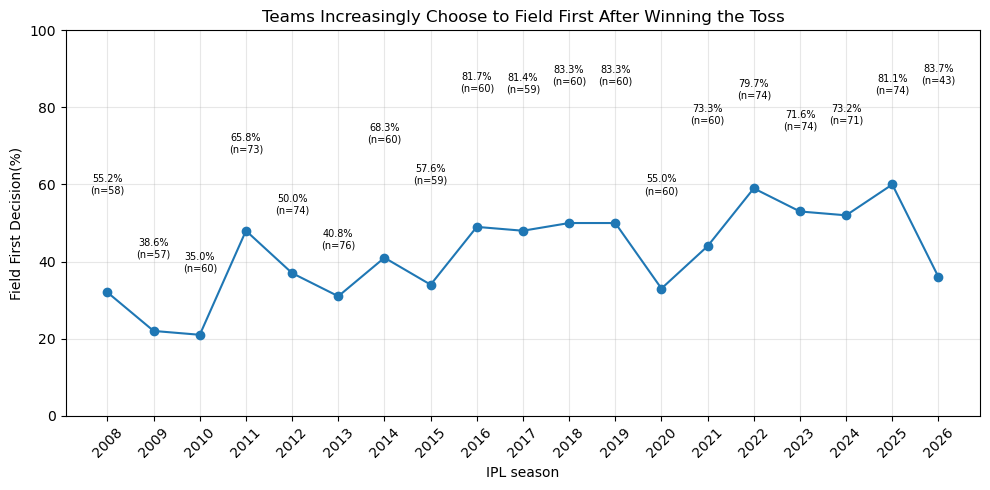

<Figure size 640x480 with 0 Axes>

In [227]:
plt.figure(figsize=(10, 5))

plt.plot(
    field_first["season_year"],
    field_first["field_first"],
    marker="o"
)

plt.xlabel("IPL season")
plt.ylabel("Field First Decision(%)")
plt.title("Teams Increasingly Choose to Field First After Winning the Toss")
plt.xticks(field_first["season_year"], rotation=45)
for x,y,n in zip(
    field_first['season_year'],
    field_first['field_first_pct'],
    field_first['total_matches']
):
    plt.annotate(
        f"{y:.1f}%\n(n={n})",
        (x,y),
        textcoords="offset points",
        xytext=(0,7),
        ha='center',
        fontsize=7)
plt.grid(True,alpha=0.3)
plt.ylim(0,100)
plt.tight_layout()
plt.show()
plt.savefig(
    "../reports/figures/field_first_trend.png",
    dpi=300,
    bbox_inches='tight')
plt.show()

In [228]:
from pathlib import Path
report_path=Path("../reports/analysis_report.md")
report_path.touch(exist_ok=True)
print(report_path)

..\reports\analysis_report.md


In [229]:
report = """# IPL Analysis Report
This report presents key business insights from the cleaned IPL dataset.
## Insight 1 — First-Innings Total and Chase Success
The analysis shows that the chase win rate decreases as the first-innings score increases, falling from **82.6% for scores below 140 (n=219)** to **23.2% for scores of 200 or more (n=198)** across **1,187 decisive matches**. This suggests that teams batting first can use higher first-innings totals to put greater pressure on the chasing team, with approximately **175 runs as a useful target to aim for**. However, the analysis does not consider factors such as **pitch conditions, player fitness, or injuries**, which may also affect match outcomes. As a validation check, the **1,187 decisive matches identified in SQL were cross-checked in Excel, which also returned 1,187 matches**.
![Chase Win Rate](figures/chase_win_rate.png)
## Insight 2 — Toss Result and Match Success
The analysis shows that the **toss winner also won the match in 613 out of 1,187 decisive matches (51.64%)**, while the toss winner did not win in 574 matches. This suggests that **winning the toss alone does not show a strong advantage in determining the final match result**, since the outcomes are nearly evenly split. Therefore, teams should **not rely on the toss result alone when making match strategies and should also consider factors such as batting performance, bowling performance, and match conditions**.
![Toss Result](figures/toss_result.png)
## Insight 3 — Field-First Decisions Over Time
The analysis shows that the preference for **fielding first after winning the toss increased over time**. Field-first decisions were **55.17% in 2008, 38.60% in 2009, and 35.00% in 2010**, while they exceeded **80% in each season from 2016 to 2019**. This indicates a clear shift in team strategy toward choosing to chase during that period. Therefore, teams should **consider the increasing preference for chasing when planning toss strategy, while also evaluating season and match conditions rather than assuming that fielding first is always the better option**.
![Field-First Trend](figures/field_first_trend.png)
"""
report_path.write_text(report, encoding="utf-8")
print("Analysis report saved.")

Analysis report saved.


In [230]:
from pathlib import Path
files_to_check=[
    "../reports/analysis_report.md",
    "../reports/figures/chase_win_rate.png",
    "../reports/figures/toss_result.png",
    "../reports/figures/field_first_trend.png"]
for file in files_to_check:
    path=Path(file)
    print(path.name," ",'EXISTS'  if path.exists() else "MISSING")

analysis_report.md   EXISTS
chase_win_rate.png   EXISTS
toss_result.png   EXISTS
field_first_trend.png   EXISTS
